In [1]:
"""
A burner-stabilized fuel-lean premixed methane-air flame at 1 atm pressure.

"""

import cantera as ct
import numpy as np
import matplotlib.pyplot as plt


In [2]:
gas_norm = ct.Solution('ffcm-1.yaml')

#air = O2:2.0, N2:7.438 , AR:0.0857' 
#Defining the mole fractions in reactants gas flow for methane air mixture:  1*CH4 + 2*(O2 + 3.719N2 + 0.0428Ar) = CO2 + 2*H2O
#phi = 1.0
#reactants = 'CH4:'+ str(np.around(phi,2)) + ', O2:2.0, N2:7.438 , AR:0.0857'  # premixed gas composition

# Define the oxidizer composition, here air with 21 mol-% O2 and 79 mol-% N2
air = "O2:0.21,N2:0.79"
# Set the mixture composition according to the stoichiometric mixture
# (equivalence ratio phi = 1). The fuel composition in this example
# is set to 100 mol-% CH4 and the oxidizer to 21 mol-% O2 and 79 mol-% N2.
# This function changes the composition of the gas object and keeps temperature
# and pressure constant
phi_norm=1.00

gas_norm.set_equivalence_ratio(phi=phi_norm, fuel="CH4:1", oxidizer=air)

T_norm = 273.15
p_norm = ct.one_atm

gas_norm.TP = T_norm, p_norm

print("\n")
print(f"phi = {phi_norm:1.3f}")
print("\n")
print(f"mass fraction of CH4 = {gas_norm['CH4'].Y[0]:1.3f}")
print(f"mass fraction of O2 = {gas_norm['O2'].Y[0]:1.3f}")
print(f"mass fraction of N2 = {gas_norm['N2'].Y[0]:1.3f}")
print("\n")
print(f"mole fraction of CH4 = {gas_norm['CH4'].X[0]:1.5f}")
print(f"mole fraction of O2 = {gas_norm['O2'].X[0]:1.5f}")
print(f"mole fraction of N2 = {gas_norm['N2'].X[0]:1.5f}")

summole_teor = gas_norm['CH4'].X[0] + (gas_norm['O2'].X[0] + gas_norm['N2'].X[0])
print(" => Sum of mole fractions (fuel & air) = ", np.round(summole_teor,3))
print("\n")

qvfu2qvox_teor = gas_norm['CH4'].X[0] / (gas_norm['O2'].X[0] + gas_norm['N2'].X[0])
print(" => Volumetric flow rate (fuel to air) ratio = ", np.round(qvfu2qvox_teor,3))
print("\n")




phi = 1.000


mass fraction of CH4 = 0.055
mass fraction of O2 = 0.220
mass fraction of N2 = 0.725


mole fraction of CH4 = 0.09502
mole fraction of O2 = 0.19005
mole fraction of N2 = 0.71493
 => Sum of mole fractions (fuel & air) =  1.0


 => Volumetric flow rate (fuel to air) ratio =  0.105




In [3]:
burnerarea = 0.00113

#burnerarea_central = 0.00116
#burnerarea_coflow = 0.00139
#burnerarea = burnerarea_central + burnerarea_coflow

qtot_norm = 4

qvfu_teor = qtot_norm * gas_norm['CH4'].X[0]
print(" => Volumetric flow rate of FUEL (desired) = ", np.round(qvfu_teor,3))

qvox_teor = qtot_norm * (gas_norm['O2'].X[0] + gas_norm['N2'].X[0])
print(" => Volumetric flow rate of AIR (desired) = ", np.round(qvox_teor,3))
print("\n")

#Volumetric flowrate of fuel and oxidizer(air) - setup of mass-flow controllers
qvfu_calibr = 0.49
conv_fluidat = 1.3
qvfu_factor= 1/conv_fluidat
qvox_calibr = 3.6
qvox_factor = 1.0

#Correction for preheated mixture flow rate compared to cold flow of reactants
qvfu_normlpermin = qvfu_calibr * qvfu_factor
qvox_normlpermin = qvox_calibr * qvox_factor

qvsum_normlpermin = qvfu_normlpermin + qvox_normlpermin
print("Volumetric flow rate of FUEL (realistic) = ", qvfu_normlpermin)
print("Volumetric flow rate of AIR (realistic) = ", qvox_normlpermin)
print("\n")
print("Experimental fuel to air ratio = ", qvfu_normlpermin/qvox_normlpermin)
print("Theoretical fuel to air ratio = ", qvfu2qvox_teor)
print("Deviation of fuel to air ratio = ", qvfu_normlpermin/qvox_normlpermin - qvfu2qvox_teor)

#Recalculate volumetric flow rate at normal conditions from [L_N/min] to [m_N^3/s] (x 0.001/60)
qvsum_mcubicpers = qvsum_normlpermin * 0.001/60

#Calculate mass flux (mdot) and inlet velocity of reactants at 300 K 
mdot = qvsum_mcubicpers*gas_norm.density_mass/burnerarea

#Recalculate mass flux (mdot) from [kg/(m^2*s)] to [g/cm^2*s)] (x 1000/10000 = 0.1)

mdot_cgs = mdot * 0.1

print("\n")
print("mdot [kg/(m^2*s)] = ", mdot)
#print("mdot [g/(cm^2*s)] = ", mdot_cgs)
print("\n")

vel_norm = mdot/gas_norm.density_mass

print("Density of reactants at normal cond. [kg/m^3] = ", np.round(gas_norm.density_mass,3))
print("Inlet velocity of reactants at normal cond. [cm/s] = ",np.round(vel_norm,4) * 100)


 => Volumetric flow rate of FUEL (desired) =  0.38
 => Volumetric flow rate of AIR (desired) =  3.62


Volumetric flow rate of FUEL (realistic) =  0.37692307692307686
Volumetric flow rate of AIR (realistic) =  3.6


Experimental fuel to air ratio =  0.10470085470085468
Theoretical fuel to air ratio =  0.10499999999999998
Deviation of fuel to air ratio =  -0.0002991452991453064


mdot [kg/(m^2*s)] =  0.07231636203092495


Density of reactants at normal cond. [kg/m^3] =  1.233
Inlet velocity of reactants at normal cond. [cm/s] =  5.87


In [4]:
#atmospheric pressure (in the LAB)
p_lab_hPa = 1013
p_lab = 100 * p_lab_hPa

#burner temperature 
tburner = 50.0 #degree Celsius
T_preheat = tburner + 273.15

#Definition of chemical kinetic scheme ("CHEMKIN-like" YAML file)
gas = ct.Solution('ffcm-1.yaml')
#gas = ct.Solution('gri30.yaml')

gas.TP = T_preheat, p_lab

gas.set_equivalence_ratio(phi=phi_norm, fuel="CH4:1", oxidizer=air)
#qvn_state_corr = 1/((p_norm*T_preheat)/(p_lab*T_norm))

print("\n")
print("T_preheat [K] = ", T_preheat)
print("p_lab [Pa] = ", p_lab)
#print("(p1*T2)/(p2*T1) = " , (p_norm*T_preheat)/(p_lab*T_norm))
print("\n")

vel_T_preheat = mdot/gas.density_mass

print("Density of preheated reactants [kg/m^3] = ", np.round(gas.density_mass,3))
print("Inlet velocity of preheated reactants [cm/s] = ",np.round(vel_T_preheat,5) * 100)




T_preheat [K] =  323.15
p_lab [Pa] =  101300


Density of preheated reactants [kg/m^3] =  1.042
Inlet velocity of preheated reactants [cm/s] =  6.941


In [5]:
#Computational domain (regular grid)

width = 0.015 # m
grid = np.linspace(0, width, 61, endpoint=True)
loglevel = 1  # amount of diagnostic output (0 to 8)

#f = ct.BurnerFlame(gas, width=width)
f = ct.BurnerFlame(gas, grid=grid)
f.burner.mdot = mdot

# Tolerance pro steady-state a transientní řešení
tol_ss = [1.0e-5, 1.0e-13]
tol_ts = [1.0e-4, 1.0e-10]
f.flame.set_steady_tolerances(default=tol_ss)
f.flame.set_transient_tolerances(default=tol_ts)

# Časové krokování – postupně větší kroky
f.set_time_step(5.0e-3, [2, 4, 8, 16, 32])

# Kritéria zjemňování sítě
f.set_refine_criteria(ratio=5.0, slope=0.25, curve=0.25, prune=0.01)
f.set_max_jac_age(ss_age=10, ts_age=10)



*********** Solving on 61 point grid with energy equation enabled ************

..............................................................................

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 2 timesteps.
Final timestep info: dt= 1.831e-06  log(ss)= 6.312     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 4 timesteps.
Final timestep info: dt= 4.12e-06   log(ss)= 6.084     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 8 timesteps.
Final timestep info: dt= 1.39e-05   log(ss)= 6.473     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 16 timesteps.
Final timestep info: dt= 3.52e-05   log(ss)= 6.407     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 32 timesteps.
Final timestep info: dt= 4.228e-05  log(ss)= 6.284     

Attempt Newton solution of 

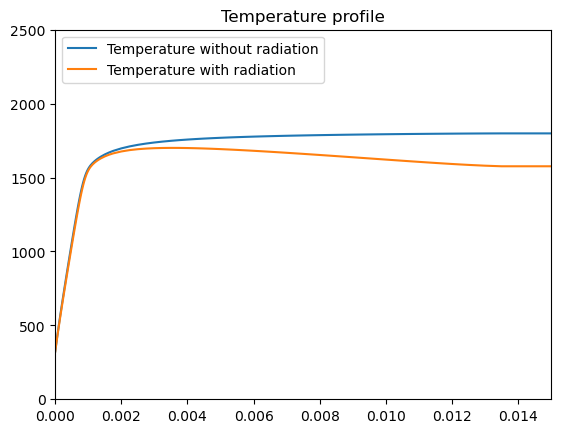

In [6]:
#0) don't solve the energy equation
f.energy_enabled = False

# 1) Mixture-averaged transport
f.transport_model = "mixture-averaged"
f.solve(loglevel, auto=True, refine_grid=False)

# 2) Multikomponentní difuze + Soretův efekt
f.energy_enabled = True
f.transport_model = "multicomponent"
f.soret_enabled = True
f.radiation_enabled = False
f.solve(loglevel, refine_grid=True)
#f.show()

# Export CSV
f.save(f"phi{phi_norm:.2f}_burner_flame_noRAD.csv", basis="mole", overwrite=True)

# Statistiky
f.show_stats(0)

# Plot teploty bez radiace
plt.figure()
plt.plot(f.flame.grid, f.T, label="Temperature without radiation")
plt.title("Temperature profile")
plt.ylim(0, 2500)
plt.xlim(0.000, width)

# Upravit kritéria zjemňování sítě
f.set_refine_criteria(ratio=2.0, slope=0.025, curve=0.01, prune=0.01)
f.set_max_jac_age(ss_age=20, ts_age=20)

# 3) Zapnout radiaci a znovu řešit

f.radiation_enabled = True
f.solve(loglevel=1, refine_grid=False)
#f.show()
# Statistiky
f.show_stats(0)
#f.write_csv(f"phi{phi_norm:.2f}_burner_flame_RADcal.csv", quiet=False)
f.save(f"phi{phi_norm:.2f}_burner_flame_RAD.csv", basis="mole", overwrite=True)

# Plot teploty s radiací
plt.plot(f.flame.grid, f.T, label="Temperature with radiation")
plt.legend(loc="upper left")
plt.savefig("burner_flame_T_fxRAD.pdf")
#plt.show()

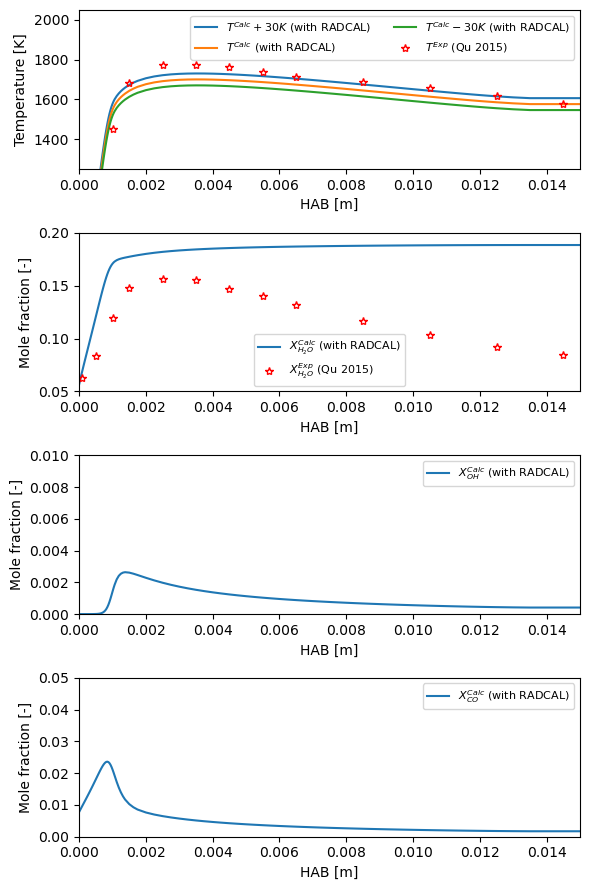

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Výsledky z Cantery
z = f.flame.grid
T = f.T

# Experimentální data (příklad – můžeš si je upravit podle potřeby)
zTexp4Qu = [0.0000,0.0005,0.001,0.0015,0.0025,0.0035,0.0045,0.0055,0.0065,0.0085,0.0105,0.0125,0.0145]
Texp4Qu  = [816,1066,1451,1683,1774,1772,1762,1740,1712,1688,1658,1619,1579]

zH2Oexp4Qu = [0.0001, 0.0005, 0.0010, 0.0015, 0.0025, 0.0035, 0.0045, 0.0055, 0.0065, 0.0085, 0.0105, 0.0125, 0.0145]
H2Oexp4Qu  = [0.0631, 0.0831, 0.119, 0.148, 0.156, 0.155, 0.147, 0.140, 0.132, 0.117, 0.103, 0.0919, 0.0849]

#zH2OexpQu = [0.0000,0.0005,0.001,0.0015,0.0025,0.0035,0.0045,0.0055,0.0065,0.0085,0.0105,0.0125,0.0145]
#H2OexpQu  = [0.083,0.114,0.152,0.169,0.172,0.176,0.172,0.175,0.172,0.171,0.169,0.157,0.155]

# --- Plotování ---
fig = plt.figure(figsize=(6,9))

# 1) Teplota
ax1 = fig.add_subplot(411)
ax1.plot(z, T+30, label=r'$T^{Calc} + 30K $ (with RADCAL)')
ax1.plot(z, T, label=r'$T^{Calc}$ (with RADCAL)')
ax1.plot(z, T-30, label=r'$T^{Calc} - 30K $ (with RADCAL)')
#ax1.plot(zTexpRu, TexpRu, 'o', color='k', fillstyle='none', label=r'$T^{Exp}$ (Rutkowski 2016)')
ax1.plot(zTexp4Qu, Texp4Qu, '*', color='r', fillstyle='none', label=r'$T^{Exp}$ (Qu 2015)')
ax1.set_xlabel("HAB [m]")
ax1.set_ylabel("Temperature [K]")
ax1.set_xlim(0,0.015)
ax1.set_ylim(1250,2050)
ax1.legend(fontsize=8, loc="best", ncol=2)

# 2) H2O
ih2o = gas.species_index('H2O')
h2o = np.zeros(f.flame.n_points)
for n in range(f.flame.n_points):
    f.set_gas_state(n)
    h2o[n] = gas.X[ih2o]

ax2 = fig.add_subplot(412)
ax2.plot(z, h2o, label=r'$X_{H_2O}^{Calc}$ (with RADCAL)')
ax2.plot(zH2Oexp4Qu, H2Oexp4Qu, '*', color='r', fillstyle='none', label=r'$X_{H_2O}^{Exp}$ (Qu 2015)')
ax2.set_xlabel("HAB [m]")
ax2.set_ylabel("Mole fraction [-]")
ax2.set_xlim(0,0.015)
ax2.set_ylim(0.05,0.2)
ax2.legend(fontsize=8, loc="best")

# 3) OH
ioh = gas.species_index('OH')
oh = np.zeros(f.flame.n_points)
for n in range(f.flame.n_points):
    f.set_gas_state(n)
    oh[n] = gas.X[ioh]

ax3 = fig.add_subplot(413)
ax3.plot(z, oh, label=r'$X_{OH}^{Calc}$ (with RADCAL)')
#ax3.plot(zOHexpRu, OHexpRu, 'o', color='k', fillstyle='none', label=r'$X_{OH}^{Exp}$ (Rutkowski 2016)')
ax3.set_xlabel("HAB [m]")
ax3.set_ylabel("Mole fraction [-]")
ax3.set_xlim(0,0.015)
ax3.set_ylim(0,0.01)
ax3.legend(fontsize=8, loc="best")

# 3) CO
ico = gas.species_index('CO')
co = np.zeros(f.flame.n_points)
for n in range(f.flame.n_points):
    f.set_gas_state(n)
    co[n] = gas.X[ico]

ax4 = fig.add_subplot(414)
ax4.plot(z, co, label=r'$X_{CO}^{Calc}$ (with RADCAL)')
#ax4.plot(zCOexpTW, COexpTW, 'o', color='k', fillstyle='none', label=r'$X_{CO}^{Exp}$ (This work)')
ax4.set_xlabel("HAB [m]")
ax4.set_ylabel("Mole fraction [-]")
ax4.set_xlim(0,0.015)
ax4.set_ylim(0,0.05)
ax4.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.savefig(f'phi{phi_norm:.2f}_burner_flame_profiles.pdf')
plt.show()
